In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
con = duckdb.connect()
PARQUET = "../../data/Crimes_clean.parquet"

In [5]:
cols = ['Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Location']

In [3]:
df = con.execute(f"""
    SELECT Date,
           coalesce(Year, CAST(strftime('%Y', Date) AS INTEGER)) AS Year,
           "Primary Type" AS Primary_Type,
           Description,
           "Location Description" AS Location_Description,
           Arrest,
           Domestic,
           District,
           Ward,
           "Community Area" AS Community_Area,
           Beat
    FROM read_parquet('{PARQUET}')
""").df()

In [5]:
df.head()

,Date,Year,Primary_Type,Description,Location_Description,Arrest,Domestic,District,Ward,Community_Area,Beat
0,2015-09-05 13:30:00,2015,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,009,12,61,0924
1,2015-09-04 11:30:00,2015,THEFT,POCKET-PICKING,CTA BUS,False,False,015,29,25,1511
2,2015-09-05 12:45:00,2015,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,014,35,21,1412
3,2015-09-05 13:00:00,2015,ASSAULT,SIMPLE,APARTMENT,False,True,015,28,25,1522
4,2015-09-05 10:55:00,2015,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,006,21,71,0614


In [8]:
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Hour'] = df['Date'].dt.hour


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7084435 entries, 0 to 7084434
Data columns (total 15 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Date                  datetime64[us]
 1   Year                  int64         
 2   Primary_Type          object        
 3   Description           object        
 4   Location_Description  object        
 5   Arrest                bool          
 6   Domestic              bool          
 7   District              object        
 8   Ward                  int64         
 9   Community_Area        int64         
 10  Beat                  object        
 11  Month                 int32         
 12  MonthName             object        
 13  Day                   int32         
 14  Hour                  int32         
dtypes: bool(2), datetime64[us](1), int32(3), int64(3), object(6)
memory usage: 635.1+ MB


In [15]:
# Q1 - crimes trends over the years?
yearly_trend = df.groupby('Year').size().reset_index(name='Total_Crime')
yearly_trend

,Year,Total_Crime
0,2001,3888
1,2002,345026
2,2003,471995
3,2004,467132
4,2005,449868
5,2006,445499
6,2007,435532
7,2008,419794
8,2009,385849
9,2010,369805


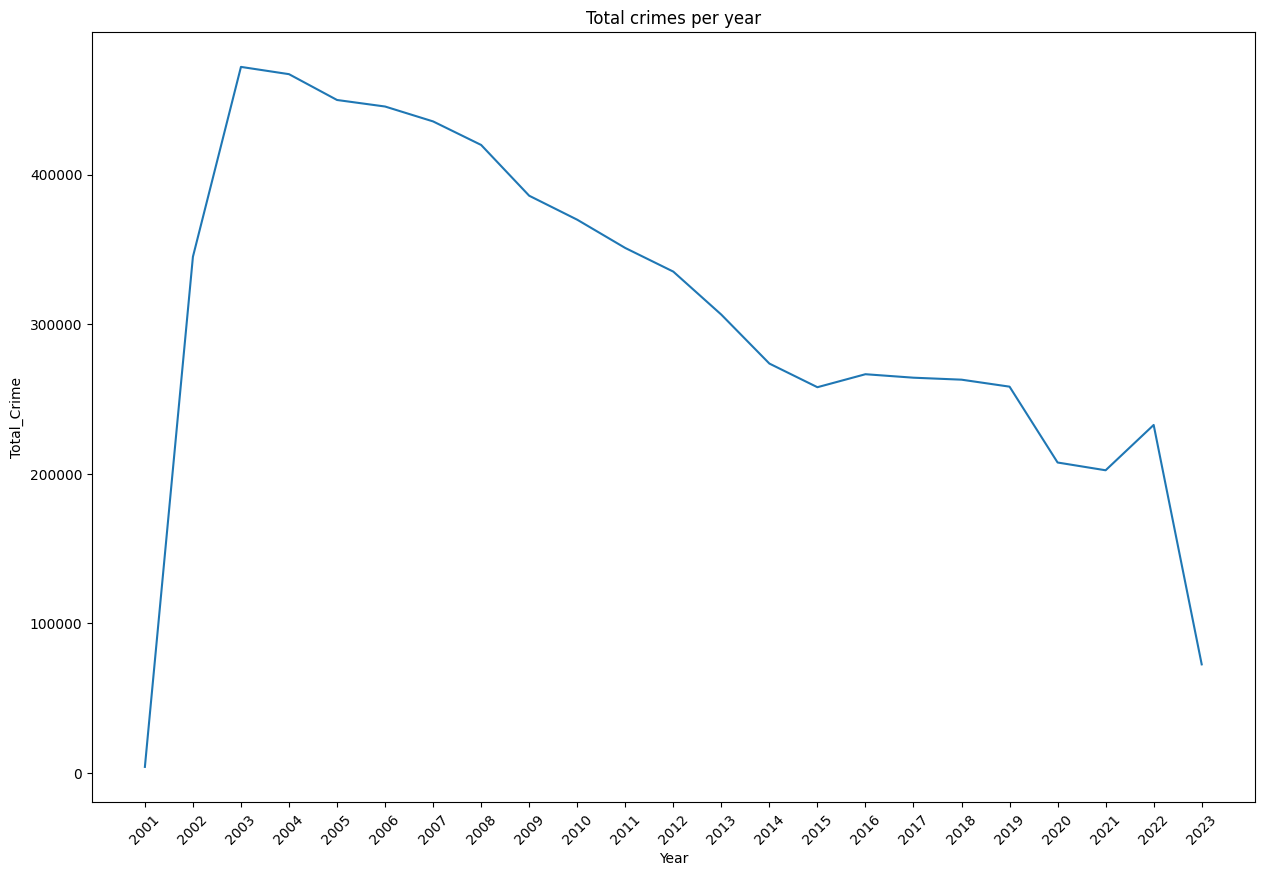

In [24]:
plt.figure(figsize=(15,10))
sns.lineplot(data=yearly_trend, x='Year', y='Total_Crime', markers='o')
plt.title('Total crimes per year')
plt.xticks(yearly_trend['Year'].astype(int).unique(), rotation=45)
plt.show()

In [29]:
# Q2 - What months has the highest number of crimes
month_trend = df.groupby('MonthName').size().reindex(['January','February','March','April','May','June','July','August','September','October','November','December']
).reset_index(name='Total')
month_trend

,MonthName,Total
0,January,538737
1,February,475877
2,March,567379
3,April,569734
4,May,635656
5,June,633272
6,July,665724
7,August,658995
8,September,619847
9,October,624718


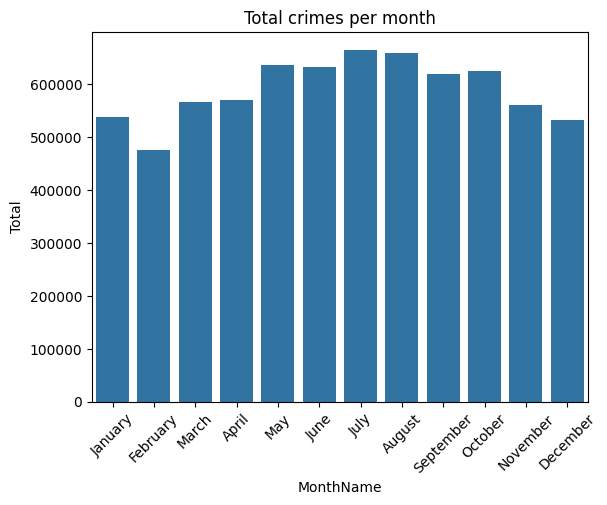

In [40]:
plt.Figure(figsize=(10,5))
sns.barplot(data=month_trend, x='MonthName', y='Total')
plt.title('Total crimes per month')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Q3 - What time of day are crimes most common 
# (morning, afternoon, night)

def time_of_day(hour):
    h = int(hour)
    if h in range(5,11): return "Morning"
    if h in range(12,17): return "Afternoon"
    if h in range(18,21): return "Evening"
    return "Night"

In [43]:
df['Time_of_day'] = df['Hour'].apply(time_of_day)
df.head()

,Date,Year,Primary_Type,Description,Location_Description,Arrest,Domestic,District,Ward,Community_Area,Beat,Month,MonthName,Day,Hour,Time_of_day
0,2015-09-05 13:30:00,2015,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,009,12,61,0924,9,September,5,13,Afternoon
1,2015-09-04 11:30:00,2015,THEFT,POCKET-PICKING,CTA BUS,False,False,015,29,25,1511,9,September,4,11,Night
2,2015-09-05 12:45:00,2015,NARCOTICS,POSS: HEROIN(BRN/TAN),SIDEWALK,True,False,014,35,21,1412,9,September,5,12,Afternoon
3,2015-09-05 13:00:00,2015,ASSAULT,SIMPLE,APARTMENT,False,True,015,28,25,1522,9,September,5,13,Afternoon
4,2015-09-05 10:55:00,2015,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,006,21,71,0614,9,September,5,10,Morning


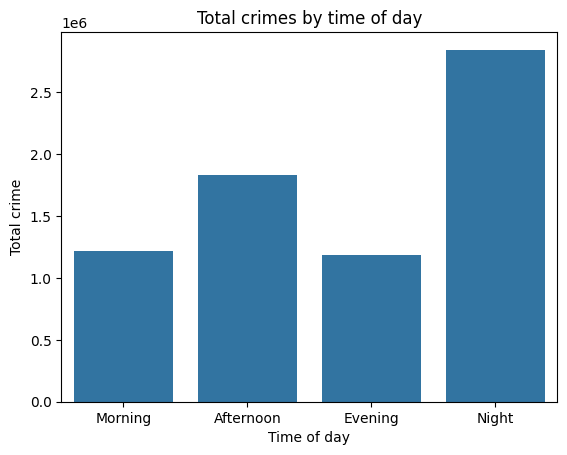

In [48]:
day_time = df['Time_of_day'].value_counts().reindex(['Morning', 'Afternoon', 'Evening', 'Night']).reset_index(name='Total Crime')
day_time.columns = ['Time of day', 'Total crime']
sns.barplot(data=day_time, x='Time of day', y='Total crime')
plt.title('Total crimes by time of day')
plt.show()

In [49]:
day_time

,Time of day,Total crime
0,Morning,1220903
1,Afternoon,1834672
2,Evening,1183698
3,Night,2845162


In [62]:
# Q4 - frequent crime categories 
#df.head()
crime_cat = df['Primary_Type'].value_counts()
print("Total Categokry: ", crime_cat.nunique())
crime_cat

Total Categokry:  35


Primary_Type
THEFT                                1499197
BATTERY                              1299859
CRIMINAL DAMAGE                       811905
NARCOTICS                             669097
ASSAULT                               465810
OTHER OFFENSE                         440288
BURGLARY                              390418
MOTOR VEHICLE THEFT                   339630
DECEPTIVE PRACTICE                    302833
ROBBERY                               267994
CRIMINAL TRESPASS                     195986
WEAPONS VIOLATION                     100385
PROSTITUTION                           61348
OFFENSE INVOLVING CHILDREN             49456
PUBLIC PEACE VIOLATION                 48705
SEX OFFENSE                            26311
CRIM SEXUAL ASSAULT                    24123
INTERFERENCE WITH PUBLIC OFFICER       17821
GAMBLING                               13405
LIQUOR LAW VIOLATION                   12782
HOMICIDE                               12168
ARSON                                  118

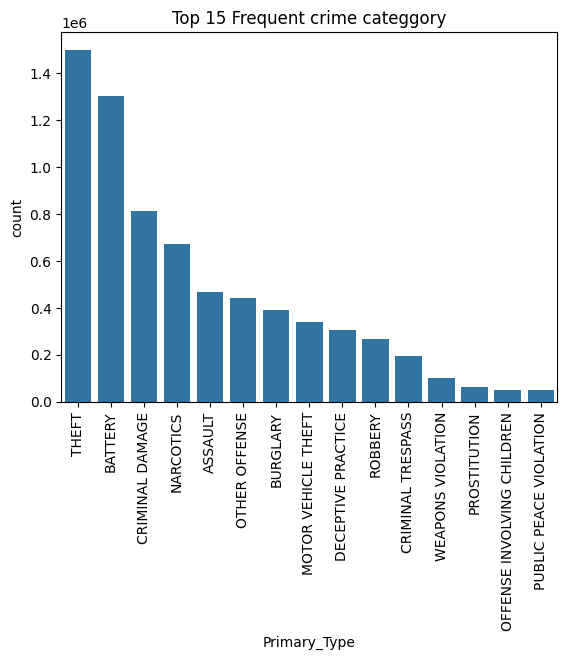

In [58]:
crime_cat_plot = crime_cat.nlargest(15)
crime_cat_plot.columns = ['Crime Type', 'Total Crime']
plt.Figure(figsize=(8,6))
sns.barplot(data=crime_cat_plot)
plt.title('Top 15 Frequent crime categgory')
plt.xticks(rotation=90)
plt.show()

In [65]:
print(df['Description'].nunique())

540


In [ ]:
# Q5 - Which crimes description are the most common
top_desc = df['Description'].value_counts().nlargest(20)
top_desc

Description
SIMPLE                           783695
DOMESTIC BATTERY SIMPLE          606759
$500 AND UNDER                   548691
TO VEHICLE                       394683
TO PROPERTY                      372788
OVER $500                        368858
AUTOMOBILE                       270364
FORCIBLE ENTRY                   260212
POSS: CANNABIS 30GMS OR LESS     256847
FROM BUILDING                    251615
RETAIL THEFT                     202427
TELEPHONE THREAT                 136415
TO LAND                          119329
UNLAWFUL ENTRY                   107161
POSS: CRACK                      101712
HARASSMENT BY TELEPHONE           98718
ARMED: HANDGUN                    85257
POSS: HEROIN(WHITE)               84842
STRONGARM - NO WEAPON             83884
AGGRAVATED: OTHER DANG WEAPON     83468
Name: count, dtype: int64

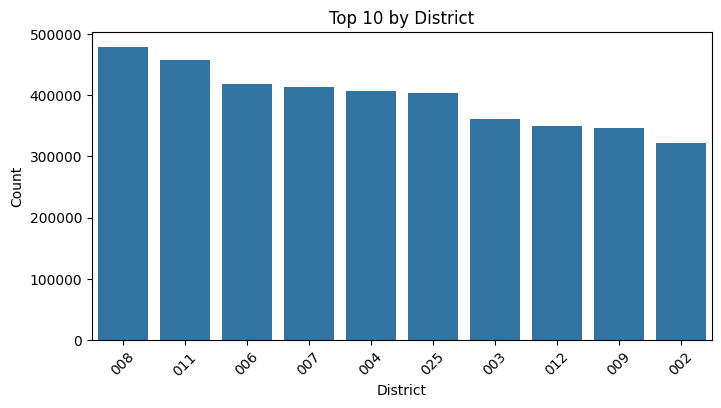

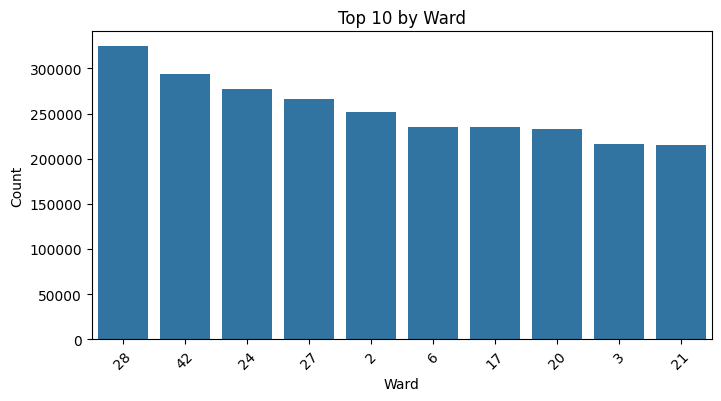

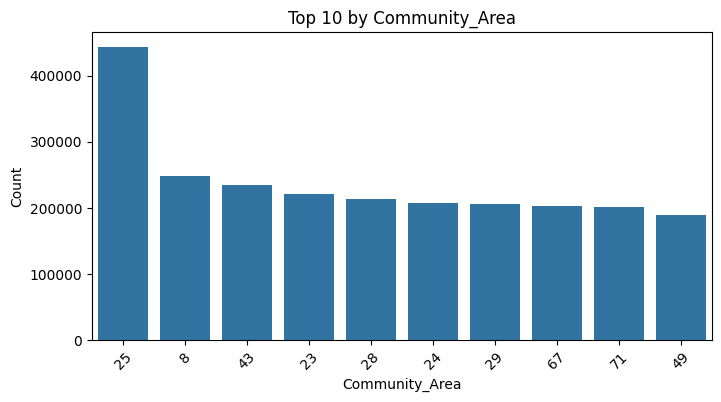

In [ ]:
# Q6 - Districts/wards/community with highest counts

for col in ['District','Ward','Community_Area']:
    top = df[col].value_counts().nlargest(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x=top.index.astype(str), y=top.values)
    plt.title(f"Top 10 by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.show()


In [91]:
# Q7 - Proportion of crimes result in arrests
arrest_rate = df['Arrest'].value_counts().reset_index(name='Total_crime')
arrest_rate.columns = ['No Arrest', 'Arrest']
sns.barplot(x=arrest_rate.index, y=arrest_rate.values)
plt.title("Arrest vs No Arrest")
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

In [88]:
arrest_rate

,No Arrest,Arrest
0,False,5250563
1,True,1833872
